# Monte Carlo Sampling from Pose Heatmaps

**Objetivo**: Demostrar el pipeline completo de muestreo estocástico desde heatmaps de pose.

## Contenido

1. **Visualización Conceptual**: Heatmaps sintéticos → muestras → estimación
2. **Comparación de Estrategias**: Rejection vs. Importance vs. Stratified
3. **Pipeline Real**: COCO dataset → Modelo → Heatmaps → Sampling
4. **Análisis de Incertidumbre**: Covarianza, ESS, diagnósticos

---

## 1. Setup: Imports y Configuración

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / "src"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import seaborn as sns

# Import our modules
from pose_uncertainty.core.sampling import (
    RejectionSampler,
    ImportanceSampler,
    StratifiedSampler,
    SamplingConfig,
    sample_from_heatmap,
    fit_gaussian_to_samples,
    estimate_effective_sample_size,
)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


## 2. Crear Heatmaps Sintéticos

Vamos a crear tres tipos de distribuciones:
- **Unimodal**: Gaussiana simple (caso ideal)
- **Bimodal**: Dos picos (ambigüedad izquierda/derecha)
- **Plana**: Distribución uniforme (máxima incertidumbre)

In [2]:
def create_gaussian_heatmap(height=64, width=48, mean=(24, 32), cov=16):
    """
    Create a 2D Gaussian heatmap.
    
    Args:
        height, width: Heatmap dimensions
        mean: (x, y) center position
        cov: Variance (scalar for isotropic)
    
    Returns:
        Normalized heatmap
    """
    y, x = np.ogrid[0:height, 0:width]
    x_centered = x - mean[0]
    y_centered = y - mean[1]
    
    exponent = -(x_centered**2 + y_centered**2) / (2 * cov)
    heatmap = np.exp(exponent).astype(np.float32)
    heatmap /= np.sum(heatmap)
    
    return heatmap


def create_bimodal_heatmap(height=64, width=48):
    """Create bimodal heatmap (left-right ambiguity)."""
    y, x = np.ogrid[0:height, 0:width]
    
    # Left peak
    gaussian1 = np.exp(-((x - 15)**2 + (y - 32)**2) / 18)
    
    # Right peak
    gaussian2 = np.exp(-((x - 33)**2 + (y - 32)**2) / 18)
    
    heatmap = (gaussian1 + gaussian2).astype(np.float32)
    heatmap /= np.sum(heatmap)
    
    return heatmap


def create_uniform_heatmap(height=64, width=48):
    """Create uniform (flat) heatmap."""
    heatmap = np.ones((height, width), dtype=np.float32)
    heatmap /= np.sum(heatmap)
    return heatmap


# Create test heatmaps
heatmap_unimodal = create_gaussian_heatmap()
heatmap_bimodal = create_bimodal_heatmap()
heatmap_uniform = create_uniform_heatmap()

print("✓ Synthetic heatmaps created")

✓ Synthetic heatmaps created


## 3. Visualización: Heatmap → Samples → Gaussian Fit

In [3]:
def plot_heatmap_and_samples(heatmap, samples, title="Sampling Visualization"):
    """
    Visualize heatmap with overlaid samples and fitted Gaussian.
    
    Args:
        heatmap: 2D probability distribution
        samples: (N, 2) array of sampled coordinates
        title: Plot title
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Original Heatmap
    ax = axes[0]
    im = ax.imshow(heatmap, cmap='hot', origin='lower', aspect='auto')
    ax.set_title('Original Heatmap', fontsize=14, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    plt.colorbar(im, ax=ax, label='Probability')
    
    # Panel 2: Heatmap + Samples
    ax = axes[1]
    ax.imshow(heatmap, cmap='hot', origin='lower', alpha=0.6, aspect='auto')
    ax.scatter(samples[:, 0], samples[:, 1], 
               c='cyan', s=1, alpha=0.5, label='Samples')
    ax.set_title(f'Samples (N={len(samples)})', fontsize=14, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    ax.legend()
    
    # Panel 3: Fitted Gaussian
    ax = axes[2]
    
    # Fit Gaussian to samples
    mean, cov = fit_gaussian_to_samples(samples)
    
    # Plot samples
    ax.scatter(samples[:, 0], samples[:, 1], 
               c='cyan', s=1, alpha=0.3, label='Samples')
    
    # Plot mean
    ax.plot(mean[0], mean[1], 'r*', markersize=15, 
            label=f'Mean: ({mean[0]:.1f}, {mean[1]:.1f})')
    
    # Plot covariance ellipse (2σ)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 1], eigenvectors[0, 1]))
    width, height = 2 * 2 * np.sqrt(eigenvalues)  # 2σ ellipse
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor='red', facecolor='none', linewidth=2,
                      label='2σ Covariance')
    ax.add_patch(ellipse)
    
    ax.set_xlim(0, heatmap.shape[1])
    ax.set_ylim(0, heatmap.shape[0])
    ax.set_title('Fitted Gaussian', fontsize=14, fontweight='bold')
    ax.set_xlabel('x (pixels)')
    ax.set_ylabel('y (pixels)')
    ax.legend()
    ax.set_aspect('equal')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n📊 Statistics:")
    print(f"   Mean: ({mean[0]:.2f}, {mean[1]:.2f})")
    print(f"   Covariance:")
    print(f"     [[{cov[0,0]:6.2f}, {cov[0,1]:6.2f}]")
    print(f"      [{cov[1,0]:6.2f}, {cov[1,1]:6.2f}]]")
    print(f"   Std Dev: ({np.sqrt(cov[0,0]):.2f}, {np.sqrt(cov[1,1]):.2f})")

### 3.1 Caso Unimodal (Gaussiana Simple)

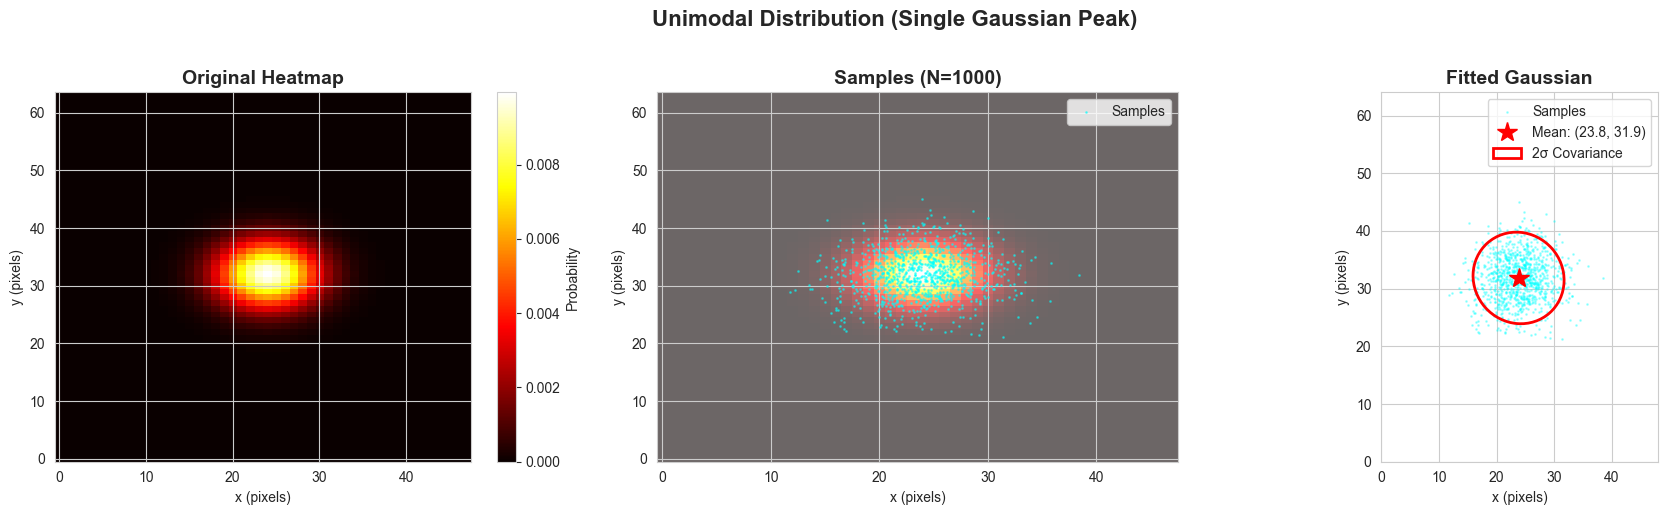


📊 Statistics:
   Mean: (23.81, 31.85)
   Covariance:
     [[ 15.74,   0.78]
      [  0.78,  15.56]]
   Std Dev: (3.97, 3.94)


In [4]:
# Sample from unimodal heatmap
samples_unimodal = sample_from_heatmap(
    heatmap_unimodal,
    num_samples=1000,
    strategy="rejection",
    seed=42
)

plot_heatmap_and_samples(
    heatmap_unimodal, 
    samples_unimodal,
    title="Unimodal Distribution (Single Gaussian Peak)"
)

### 3.2 Caso Bimodal (Ambigüedad Izquierda-Derecha)

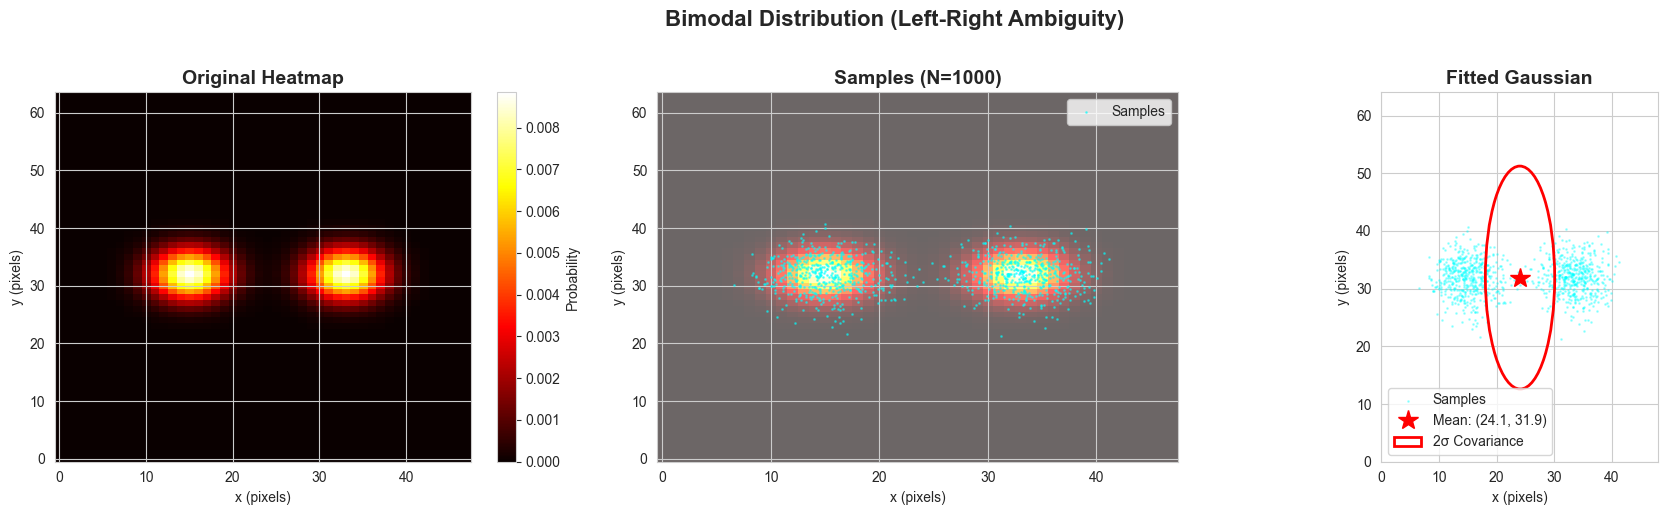


📊 Statistics:
   Mean: (24.06, 31.92)
   Covariance:
     [[ 93.32,   0.15]
      [  0.15,   9.03]]
   Std Dev: (9.66, 3.00)


In [5]:
# Sample from bimodal heatmap
samples_bimodal = sample_from_heatmap(
    heatmap_bimodal,
    num_samples=1000,
    strategy="rejection",
    seed=42
)

plot_heatmap_and_samples(
    heatmap_bimodal,
    samples_bimodal,
    title="Bimodal Distribution (Left-Right Ambiguity)"
)

## 4. Comparación de Estrategias de Muestreo

Comparamos las tres estrategias implementadas:
1. **Rejection Sampling**: Unbiased, eficiente para distribuciones peaked
2. **Importance Sampling**: Rápido, sin rechazos
3. **Stratified Sampling**: Mejor cobertura, reduce varianza

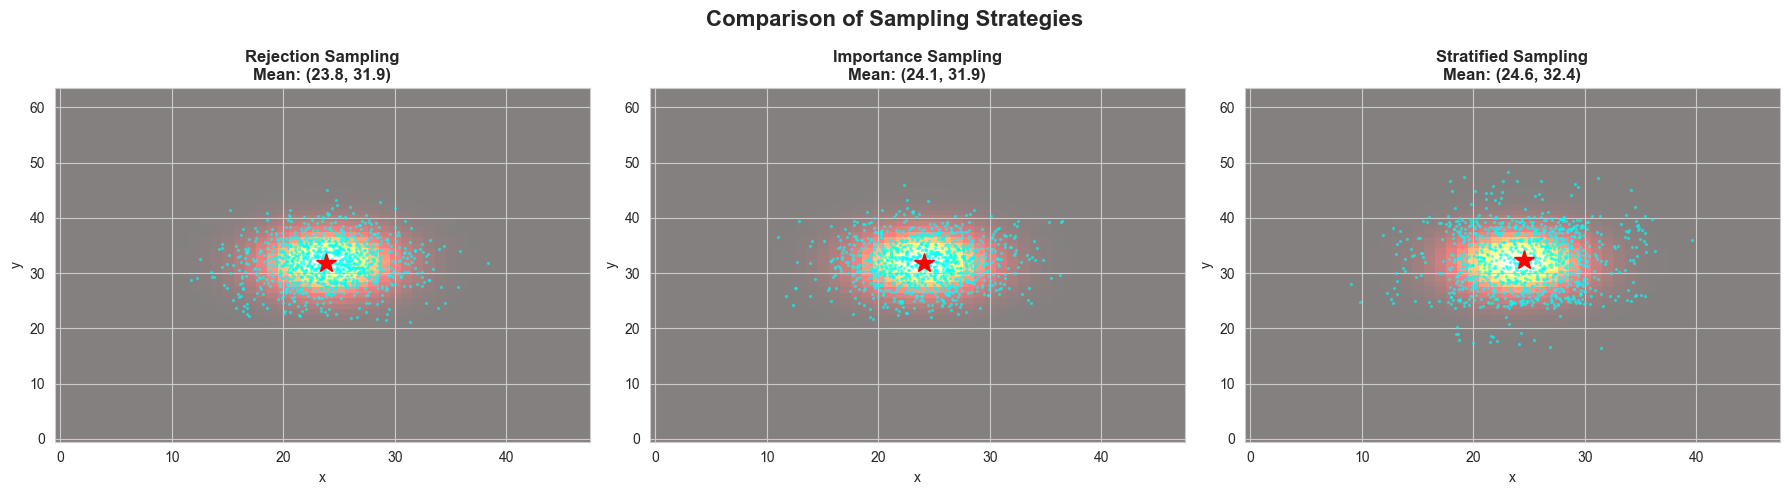


📊 Statistical Comparison:

Strategy        Mean (x, y)          Std Dev (x, y)      
Rejection       (23.81, 31.85)     ( 3.97,  3.94)
Importance      (24.09, 31.87)     ( 4.06,  3.99)
Stratified      (24.57, 32.42)     ( 4.59,  5.34)


In [6]:
def compare_sampling_strategies(heatmap, num_samples=500, seed=42):
    """
    Compare different sampling strategies on the same heatmap.
    """
    config = SamplingConfig(num_samples=num_samples, seed=seed)
    
    # Sample with each strategy
    rejection_sampler = RejectionSampler(config)
    samples_rejection = rejection_sampler.sample(heatmap)
    
    importance_sampler = ImportanceSampler(config)
    samples_importance = importance_sampler.sample(heatmap)
    
    stratified_sampler = StratifiedSampler(config, grid_size=(8, 8))
    samples_stratified = stratified_sampler.sample(heatmap)
    
    # Compute statistics
    strategies = {
        'Rejection': samples_rejection,
        'Importance': samples_importance,
        'Stratified': samples_stratified
    }
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ax, (name, samples) in zip(axes, strategies.items()):
        # Overlay samples on heatmap
        ax.imshow(heatmap, cmap='hot', origin='lower', alpha=0.5, aspect='auto')
        ax.scatter(samples[:, 0], samples[:, 1], 
                   c='cyan', s=2, alpha=0.5)
        
        # Compute mean
        mean = np.mean(samples, axis=0)
        ax.plot(mean[0], mean[1], 'r*', markersize=15)
        
        ax.set_title(f'{name} Sampling\nMean: ({mean[0]:.1f}, {mean[1]:.1f})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    
    plt.suptitle('Comparison of Sampling Strategies', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print statistical comparison
    print("\n📊 Statistical Comparison:")
    print("\n" + "="*70)
    print(f"{'Strategy':<15} {'Mean (x, y)':<20} {'Std Dev (x, y)':<20}")
    print("="*70)
    
    for name, samples in strategies.items():
        mean = np.mean(samples, axis=0)
        std = np.std(samples, axis=0)
        print(f"{name:<15} ({mean[0]:5.2f}, {mean[1]:5.2f})     ({std[0]:5.2f}, {std[1]:5.2f})")
    
    print("="*70)


# Compare strategies on unimodal heatmap
compare_sampling_strategies(heatmap_unimodal, num_samples=1000)

## 5. Análisis de Efecto de Temperatura

La temperatura controla la "peakedness" de la distribución:
- T < 1: Más concentrado (exploit)
- T = 1: Sin cambio
- T > 1: Más uniforme (explore)

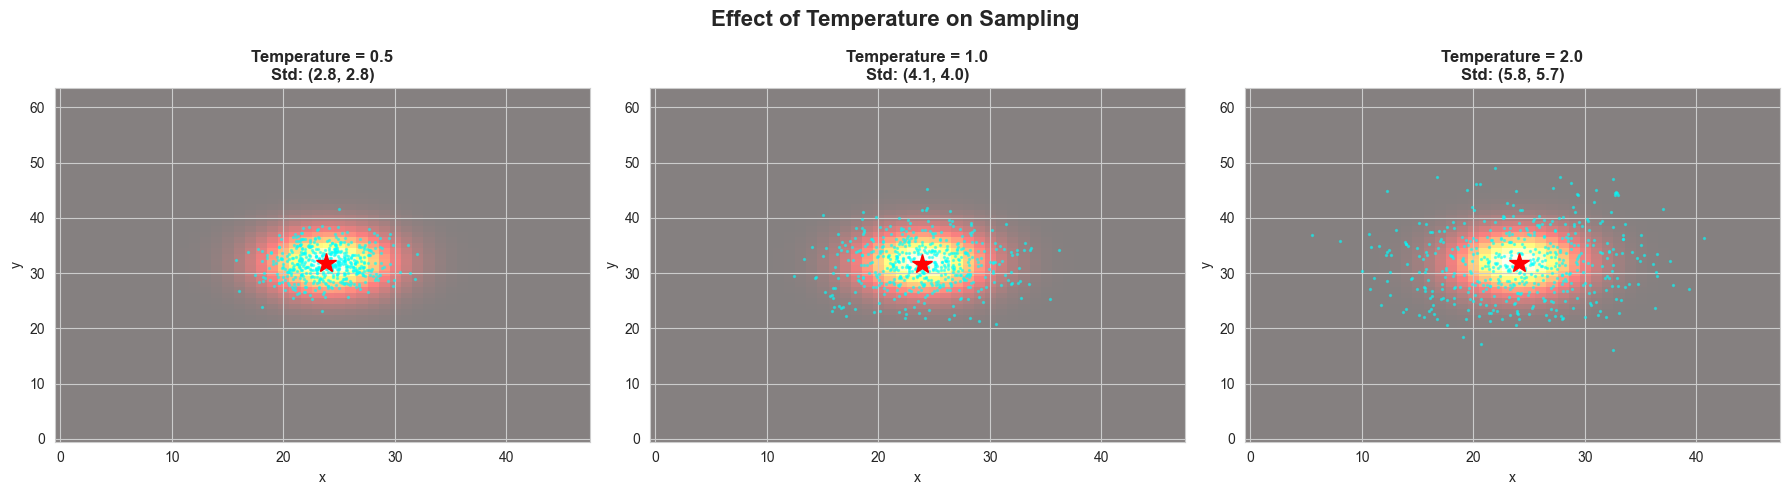

In [7]:
def visualize_temperature_effect(heatmap, temperatures=[0.5, 1.0, 2.0]):
    """
    Visualize how temperature affects sampling distribution.
    """
    fig, axes = plt.subplots(1, len(temperatures), figsize=(18, 5))
    
    for ax, temp in zip(axes, temperatures):
        samples = sample_from_heatmap(
            heatmap,
            num_samples=500,
            temperature=temp,
            seed=42
        )
        
        ax.imshow(heatmap, cmap='hot', origin='lower', alpha=0.5, aspect='auto')
        ax.scatter(samples[:, 0], samples[:, 1], c='cyan', s=2, alpha=0.5)
        
        mean = np.mean(samples, axis=0)
        std = np.std(samples, axis=0)
        
        ax.plot(mean[0], mean[1], 'r*', markersize=15)
        ax.set_title(f'Temperature = {temp}\nStd: ({std[0]:.1f}, {std[1]:.1f})',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    
    plt.suptitle('Effect of Temperature on Sampling', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_temperature_effect(heatmap_unimodal)

## 6. Pipeline Real con COCO Dataset

Ahora integramos todo el pipeline:
1. Cargar imagen desde COCO
2. Ejecutar modelo de pose (MMPose)
3. Extraer heatmaps
4. Aplicar sampling
5. Estimar incertidumbre

In [8]:
# Import data loader and model adapter
try:
    from pose_uncertainty.data_loader import COCOLoader
    from pose_uncertainty.models.adapters import MMPoseAdapter
    from pose_uncertainty.models.base import COCO_KEYPOINT_NAMES
    
    print("✓ Data loader and model adapter imported")
    
except ImportError as e:
    print(f"⚠ Could not import required modules: {e}")
    print("  This section requires COCO data and MMPose to be set up.")
    print("  Skipping real data pipeline demo.")

✓ Data loader and model adapter imported


### 6.1 Cargar Dataset COCO

In [9]:
# IMPORTANTE: Ajustar estas rutas a tu configuración
DATA_ROOT = project_root / "data" / "coco"
ANN_FILE = "annotations/person_keypoints_val2017.json"
IMAGE_DIR = "val2017"

try:
    # Initialize COCO loader
    coco_loader = COCOLoader(
        data_root=str(DATA_ROOT),
        ann_file=ANN_FILE,
        image_dir=IMAGE_DIR
    )
    
    print(f"✓ COCO dataset loaded: {len(coco_loader)} images")
    
    # Get first sample
    sample_iter = iter(coco_loader)
    sample = next(sample_iter)
    
    print(f"\n📷 Sample Image:")
    print(f"   Image ID: {sample.image_id}")
    print(f"   Path: {sample.image_path}")
    print(f"   Shape: {sample.image_array.shape}")
    print(f"   BBox: {sample.bbox}")
    print(f"   Keypoints: {len(sample.ground_truth_keypoints)}")
    
except Exception as e:
    print(f"⚠ Could not load COCO dataset: {e}")
    print("  Make sure COCO data is downloaded and paths are correct.")
    sample = None

Cargando anotaciones desde C:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=3.48s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.
✓ COCO dataset loaded: 2693 images

📷 Sample Image:
   Image ID: 532481
   Path: C:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\coco\val2017\000000532481.jpg
   Shape: (426, 640, 3)
   BBox: (250.82, 168.26, 70.11, 64.88)
   Keypoints: 17


### 6.2 Inicializar Modelo de Pose

In [10]:
# Model configuration
import os
from pose_uncertainty.models.adapters import create_model_adapter


MODEL_CONFIG = project_root / "configs" / "model" / "hrnet_w32.yaml"
MODEL_CHECKPOINT = project_root / "models" / "weights" / "hrnet_w32.pth"

try:
    PROJECT_ROOT = Path(os.getcwd()).parent.absolute()
    # Initialize model adapter
    model = create_model_adapter(
        model_name="hrnet_w32",
        device="cpu",  # Cambiar a "cpu" si no tienes GPU
        project_root=PROJECT_ROOT
    )
    
    print("✓ Model loaded successfully")
    print(f"   Config: {MODEL_CONFIG.name}")
    print(f"   Checkpoint: {MODEL_CHECKPOINT.name}")
    
except Exception as e:
    print(f"⚠ Could not load model: {e}")
    print("  Make sure model weights are downloaded and MMPose is installed.")
    model = None

Loads checkpoint by local backend from path: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\models\weights\hrnet_w32.pth
✓ Model loaded successfully
   Config: hrnet_w32.yaml
   Checkpoint: hrnet_w32.pth


### 6.3 Ejecutar Inferencia y Muestreo

Running inference...
✓ Inference complete
   Heatmap shape: (17, 48, 64)
   Num keypoints: 17
   Resolution: 48x64

📍 Analyzing keypoint: left_wrist (index 9)


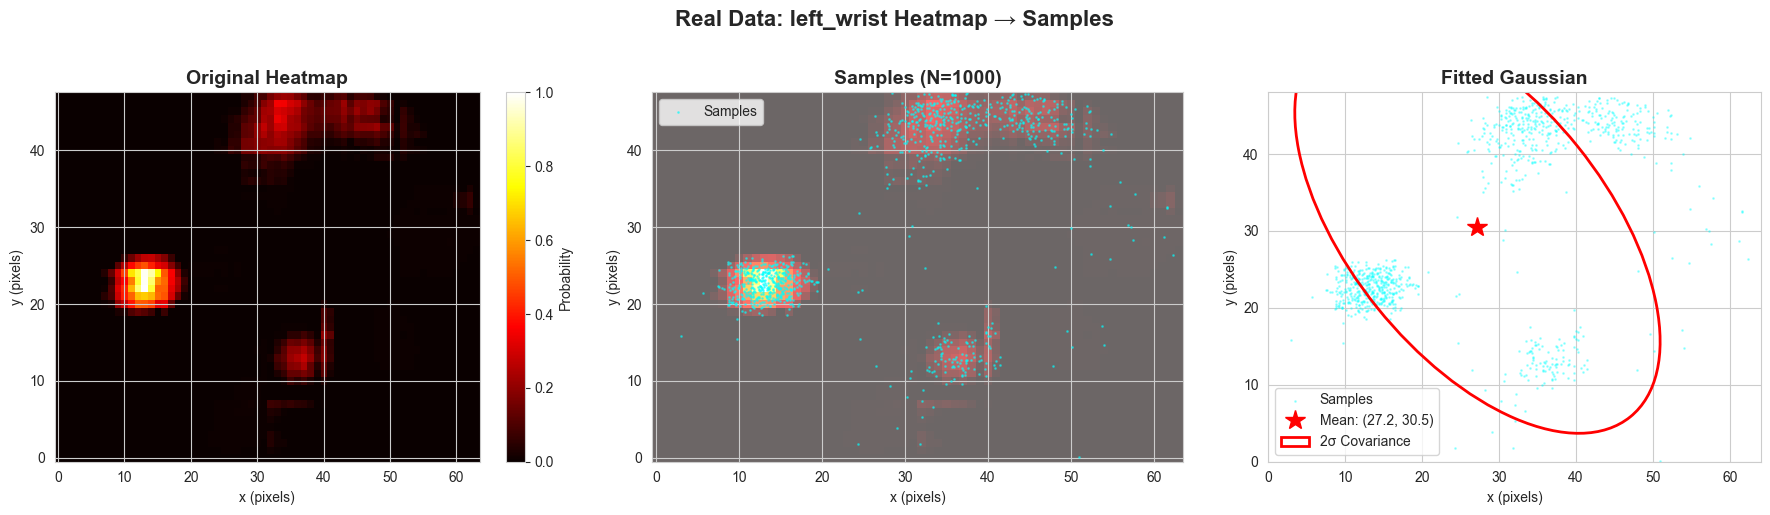


📊 Statistics:
   Mean: (27.18, 30.51)
   Covariance:
     [[179.74,  88.38]
      [ 88.38, 140.97]]
   Std Dev: (13.41, 11.87)


In [16]:
if sample is not None and model is not None:
    # Run inference
    print("Running inference...")
    heatmaps = model.predict(sample.image_array, sample.bbox)
    
    print(f"✓ Inference complete")
    print(f"   Heatmap shape: {heatmaps.data.shape}")
    print(f"   Num keypoints: {heatmaps.data.shape[0]}")
    print(f"   Resolution: {heatmaps.data.shape[1]}x{heatmaps.data.shape[2]}")
    
    # Select a keypoint to visualize (e.g., left wrist = index 9)
    keypoint_idx = 9  # left_wrist
    keypoint_name = COCO_KEYPOINT_NAMES[keypoint_idx]
    
    keypoint_heatmap = heatmaps.data[keypoint_idx]
    
    print(f"\n📍 Analyzing keypoint: {keypoint_name} (index {keypoint_idx})")
    
    # Sample from heatmap
    samples = sample_from_heatmap(
        keypoint_heatmap,
        num_samples=1000,
        strategy="rejection",
        seed=42
    )
    
    # Visualize
    plot_heatmap_and_samples(
        keypoint_heatmap,
        samples,
        title=f"Real Data: {keypoint_name} Heatmap → Samples"
    )
    
else:
    print("⚠ Skipping inference demo (data or model not available)")

### 6.4 Visualizar Múltiples Keypoints

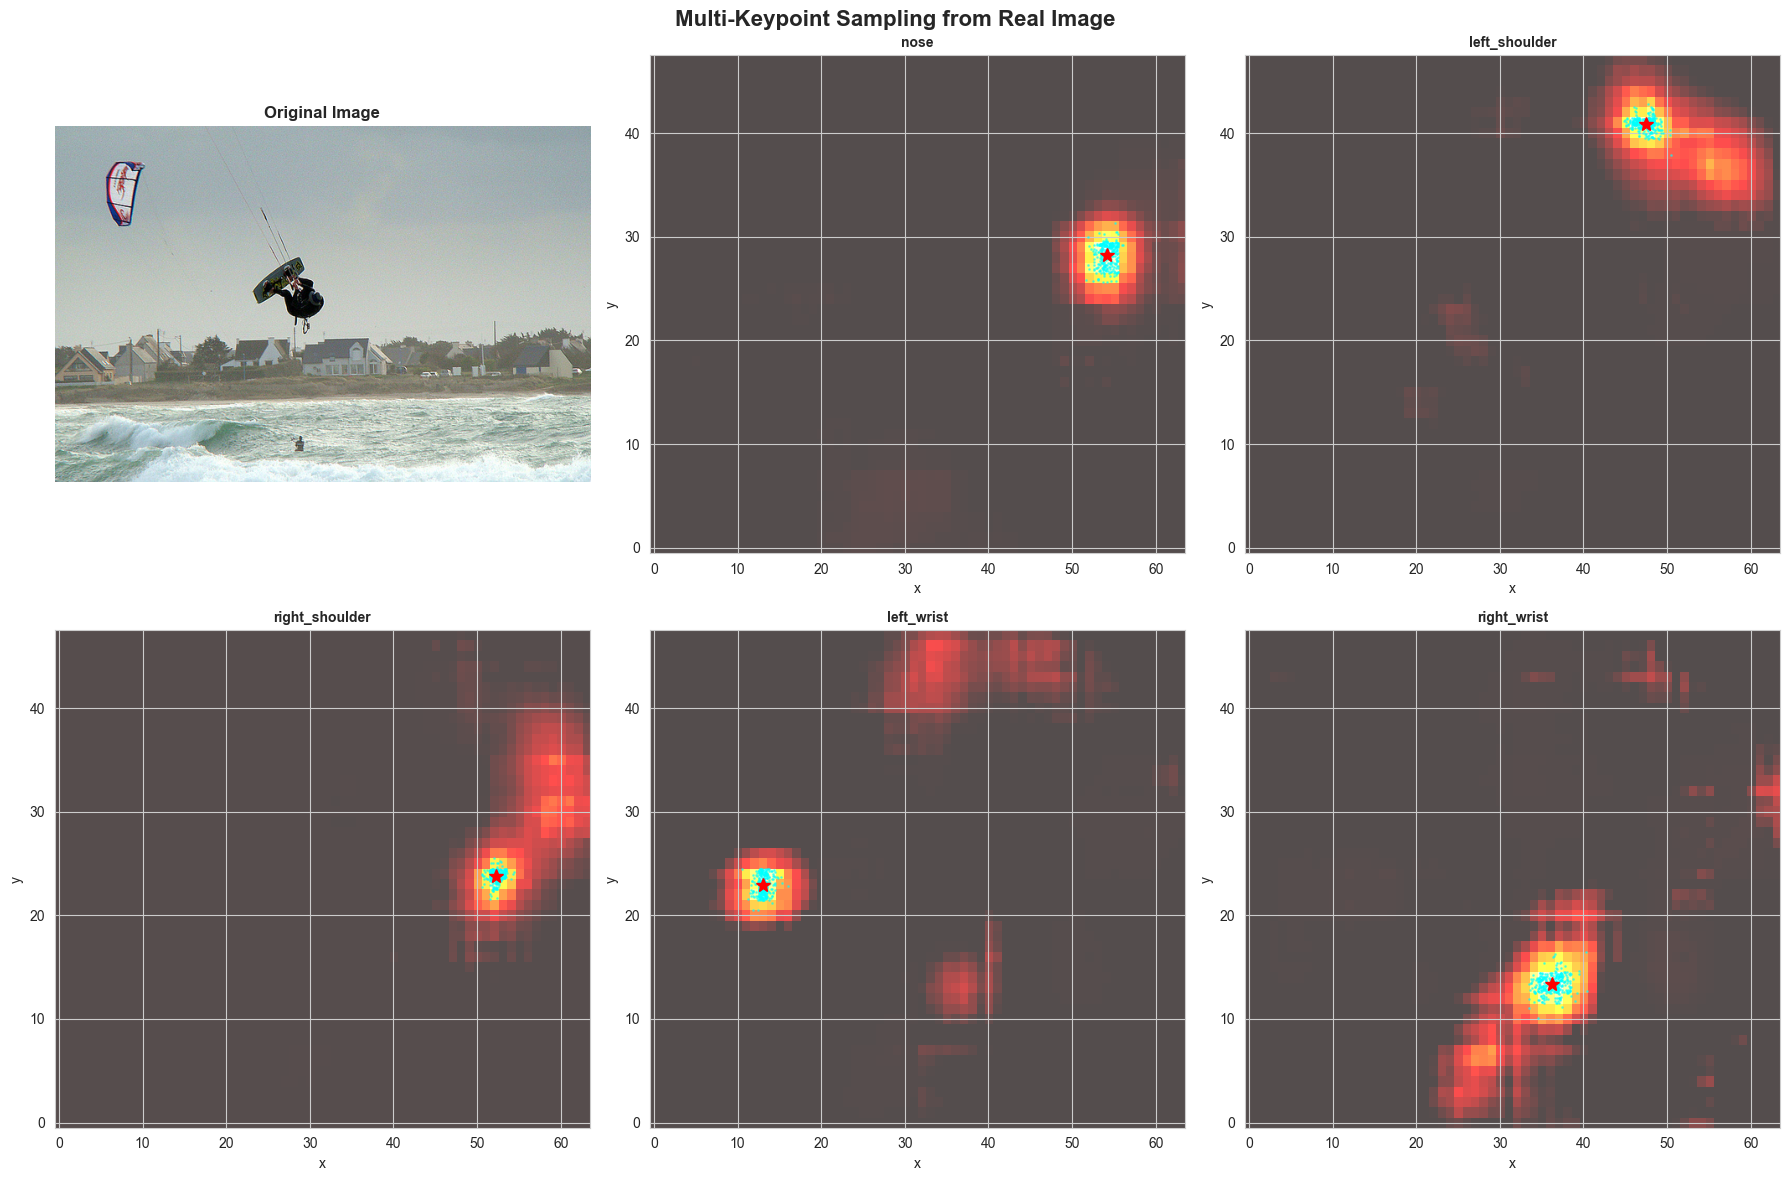

In [21]:
if sample is not None and model is not None:
    # Visualize multiple keypoints
    selected_keypoints = [0, 5, 6, 9, 10]  # nose, shoulders, wrists
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # Original image
    axes[0].imshow(sample.image_array)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Keypoint heatmaps
    for i, kp_idx in enumerate(selected_keypoints, start=1):
        kp_name = COCO_KEYPOINT_NAMES[kp_idx]
        kp_heatmap = heatmaps.data[kp_idx]
        
        # Sample
        kp_samples = sample_from_heatmap(
            kp_heatmap,
            num_samples=300,
            temperature=0.1,
            strategy="rejection",
            seed=42 + i
        )
        
        # Plot
        ax = axes[i]
        ax.imshow(kp_heatmap, cmap='hot', origin='lower', alpha=0.7, aspect='auto')
        ax.scatter(kp_samples[:, 0], kp_samples[:, 1], 
                   c='cyan', s=1, alpha=0.5)
        
        mean = np.mean(kp_samples, axis=0)
        ax.plot(mean[0], mean[1], 'r*', markersize=10)
        
        ax.set_title(f'{kp_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    
    plt.suptitle('Multi-Keypoint Sampling from Real Image', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("⚠ Skipping multi-keypoint visualization")

## 7. Análisis de Incertidumbre

Métricas cuantitativas de calidad de muestreo:
- **Effective Sample Size (ESS)**: ¿Qué tan diversos son los samples?
- **Determinante de Covarianza**: Área de incertidumbre
- **Eigenvalues**: Direcciones principales de incertidumbre

In [18]:
def analyze_uncertainty(heatmap, num_samples=1000, seed=42):
    """
    Comprehensive uncertainty analysis.
    """
    # Sample
    samples = sample_from_heatmap(heatmap, num_samples=num_samples, seed=seed)
    
    # Fit Gaussian
    mean, cov = fit_gaussian_to_samples(samples)
    
    # Compute metrics
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    det_cov = np.linalg.det(cov)
    trace_cov = np.trace(cov)
    
    # Effective sample size (assuming uniform weights)
    weights = np.ones(num_samples) / num_samples
    ess = estimate_effective_sample_size(weights)
    
    # Print report
    print("\n" + "="*70)
    print("🔍 UNCERTAINTY ANALYSIS REPORT")
    print("="*70)
    
    print(f"\n📊 Basic Statistics:")
    print(f"   Mean (x, y):        ({mean[0]:.2f}, {mean[1]:.2f})")
    print(f"   Std Dev (x, y):     ({np.sqrt(cov[0,0]):.2f}, {np.sqrt(cov[1,1]):.2f})")
    
    print(f"\n🎯 Covariance Matrix:")
    print(f"     [[{cov[0,0]:7.2f}, {cov[0,1]:7.2f}]")
    print(f"      [{cov[1,0]:7.2f}, {cov[1,1]:7.2f}]]")
    
    print(f"\n📐 Geometric Properties:")
    print(f"   Determinant:        {det_cov:.2f} (uncertainty area)")
    print(f"   Trace:              {trace_cov:.2f} (total variance)")
    print(f"   Eigenvalues:        λ₁={eigenvalues[0]:.2f}, λ₂={eigenvalues[1]:.2f}")
    print(f"   Principal Axes:     ({np.sqrt(eigenvalues[0]):.2f}, {np.sqrt(eigenvalues[1]):.2f}) pixels")
    
    print(f"\n✨ Sampling Quality:")
    print(f"   Effective Sample Size: {ess:.1f} / {num_samples} ({ess/num_samples*100:.1f}%)")
    
    if ess / num_samples > 0.9:
        print(f"   ✓ Excellent: High sample diversity")
    elif ess / num_samples > 0.5:
        print(f"   ○ Good: Moderate sample diversity")
    else:
        print(f"   ⚠ Warning: Low sample diversity (weight collapse)")
    
    print("\n" + "="*70)
    
    return mean, cov, ess


# Analyze unimodal case
print("\n🔬 Analyzing Unimodal Heatmap:")
analyze_uncertainty(heatmap_unimodal)

# Analyze bimodal case
print("\n🔬 Analyzing Bimodal Heatmap:")
analyze_uncertainty(heatmap_bimodal)


🔬 Analyzing Unimodal Heatmap:

🔍 UNCERTAINTY ANALYSIS REPORT

📊 Basic Statistics:
   Mean (x, y):        (23.81, 31.85)
   Std Dev (x, y):     (3.97, 3.94)

🎯 Covariance Matrix:
     [[  15.74,    0.78]
      [   0.78,   15.56]]

📐 Geometric Properties:
   Determinant:        244.32 (uncertainty area)
   Trace:              31.30 (total variance)
   Eigenvalues:        λ₁=14.87, λ₂=16.43
   Principal Axes:     (3.86, 4.05) pixels

✨ Sampling Quality:
   Effective Sample Size: 1000.0 / 1000 (100.0%)
   ✓ Excellent: High sample diversity


🔬 Analyzing Bimodal Heatmap:

🔍 UNCERTAINTY ANALYSIS REPORT

📊 Basic Statistics:
   Mean (x, y):        (24.06, 31.92)
   Std Dev (x, y):     (9.66, 3.00)

🎯 Covariance Matrix:
     [[  93.32,    0.15]
      [   0.15,    9.03]]

📐 Geometric Properties:
   Determinant:        842.25 (uncertainty area)
   Trace:              102.35 (total variance)
   Eigenvalues:        λ₁=9.03, λ₂=93.32
   Principal Axes:     (3.00, 9.66) pixels

✨ Sampling Quality:
 

(array([24.060173, 31.919838], dtype=float32),
 array([[93.32153   ,  0.14706276],
        [ 0.14706276,  9.025483  ]], dtype=float32),
 1000.0000000000007)

## 8. Conclusiones y Recomendaciones

### ✅ Cuándo usar cada estrategia:

1. **Rejection Sampling**:
   - ✓ Distribuciones peaked (max(P) > 0.1)
   - ✓ Garantía de muestreo exacto (unbiased)
   - ✗ Ineficiente para distribuciones planas

2. **Importance Sampling**:
   - ✓ Siempre eficiente (sin rechazos)
   - ✓ Funciona bien en todos los casos
   - ○ Recomendado como método por defecto

3. **Stratified Sampling**:
   - ✓ Mejor para distribuciones multimodales
   - ✓ Garantiza cobertura en regiones de baja probabilidad
   - ○ Ligeramente más complejo

### 📏 Parámetros recomendados:

- **num_samples**: 500-1000 (balance precisión/velocidad)
- **batch_size**: 5000-10000 para rejection sampling
- **use_dequantization**: Siempre True (evita matrices singulares)
- **jitter_magnitude**: 0.5 (uniforme sobre píxel)
- **temperature**: 1.0 (sin modificación), o 0.7-1.3 para ajustes

### 🎯 Próximos pasos:

1. Integrar con Gaussian Mixture Models (GMM)
2. Implementar Test-Time Adaptation (TTA)
3. Evaluar en benchmarks (COCO, CrowdPose, OCHuman)

---
**Autor**: TFG Informática - ETH Zürich Standards  
**Fecha**: 2026  
**Módulo**: `pose_uncertainty.core.sampling`